# Compare NARR-PRISM Inference With PRISM Observations

This notebook reads a NARR-PRISM YAML configuration, finds the matching inference outputs, and compares them with daily PRISM files over the configured spatial subdomain.

Outputs include climatology comparison maps and GIF animations for `ppt`, `tmax`, and `tmin`.

In [1]:
from pathlib import Path
import hashlib
import json
import re
import sys

import numpy as np
import pandas as pd
import xarray as xr
import yaml

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    CARTOPY_AVAILABLE = True
except ImportError:
    ccrs = None
    cfeature = None
    CARTOPY_AVAILABLE = False

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "granitewxc").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "examples" / "NARR_PRISM"))
    sys.path.insert(0, str(REPO_ROOT))

from narr_prism_utils import case_output_dir, get_case_name, resolve_path
from granitewxc.utils.prism_evaluation import exact_axis_slice, validate_evaluation_coordinates
from granitewxc.utils.prism_grid import load_canonical_grid

print(f"Repository root: {REPO_ROOT}")
print(f"Cartopy available: {CARTOPY_AVAILABLE}")

Repository root: /data/granite-wxc
Cartopy available: True


## User Parameters

In [2]:
# ===================== USER PARAMETERS (EDIT ME) =====================
CONFIG_PATH = REPO_ROOT / "examples" / "NARR_PRISM" / "NARR_PRISM_subdomain.yaml"

# Leave as None to use data.target_dir and inference.output_dir from the YAML.
PRISM_ROOT = None
INFERENCE_OUTPUT_ROOT = None

# Climatology period. None means use the YAML inference period, clipped to files found.
# For faster first runs, set a smaller range such as "2016-01-01" to "2016-12-31".
CLIMO_START = None
CLIMO_END = None
FORCE_RECOMPUTE_CLIMO = False  # Reuse the saved NetCDF climatology when available.
USE_PREPROCESSED_PRISM = False  # Optional canonical-target source; raw PRISM is faster on this filesystem.

# GIF period should stay modest because every frame reads PRISM + inference data.
GIF_START = "2025-07-01"
GIF_END = "2025-07-31"
GIF_FPS = 2

OUTPUT_DIR = REPO_ROOT / "examples" / "NARR_PRISM" / "experiments" / "comparison_plots"
MAKE_GIFS = True

# Map backgrounds use Cartopy PlateCarree when available.
USE_CARTOPY = True
SHOW_COUNTIES = False  # County boundaries can trigger a Natural Earth download.
MAP_FEATURE_SCALE = "10m"  # "10m", "50m", or "110m"
COUNTY_FEATURE_SCALE = "10m"
# ====================================================================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Comparison artifacts will be written to: {OUTPUT_DIR}")

Comparison artifacts will be written to: /data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots


## Load Configuration

In [3]:
with open(CONFIG_PATH, "r", encoding="utf-8") as fh:
    cfg = yaml.safe_load(fh)

data_cfg = cfg["data"]
case_name = get_case_name(cfg)
target_variables = list(data_cfg.get("target_variables", ["ppt", "tmax", "tmin"]))
spatial_subset = data_cfg.get("spatial_subset", {}) or {}

prism_root = Path(PRISM_ROOT) if PRISM_ROOT is not None else Path(data_cfg["target_dir"])
inference_root = (
    Path(INFERENCE_OUTPUT_ROOT)
    if INFERENCE_OUTPUT_ROOT is not None
    else resolve_path(cfg.get("inference", {}).get("output_dir", "./examples/NARR_PRISM/experiments/inference_output"))
)
inference_dir = case_output_dir(inference_root, case_name)
preprocessed_case_dir = case_output_dir(resolve_path(data_cfg["preprocessed_dir"]), case_name)
canonical_grid = load_canonical_grid(preprocessed_case_dir)

yaml_start = pd.Timestamp(cfg["dates"]["inference"]["start"])
yaml_end = pd.Timestamp(cfg["dates"]["inference"]["end"])

print(f"Config: {CONFIG_PATH}")
print(f"Case name: {case_name}")
print(f"Variables: {target_variables}")
print(f"PRISM root: {prism_root}")
print(f"Inference dir: {inference_dir}")
print(f"Canonical PRISM grid: {canonical_grid.shape} ({canonical_grid.fingerprint[:12]})")
print(f"PRISM comparison source: {'canonical preprocessed targets' if USE_PREPROCESSED_PRISM else 'raw daily files'}")
print(f"YAML inference period: {yaml_start.date()} to {yaml_end.date()}")
print(f"Spatial subset: {spatial_subset}")

Config: /data/granite-wxc/examples/NARR_PRISM/NARR_PRISM_subdomain.yaml
Case name: narr_prism_California
Variables: ['ppt', 'tmax', 'tmin']
PRISM root: /data/PRISM/prism_daily_800m_an
Inference dir: /data/granite-wxc/examples/NARR_PRISM/experiments/inference_output/narr_prism_California
Canonical PRISM grid: (1024, 1024) (f062e76bd115)
PRISM comparison source: raw daily files
YAML inference period: 2016-01-01 to 2025-12-31
Spatial subset: {'enabled': True, 'lat_min': 32.55, 'lat_max': 41.075, 'lon_min': -124.45, 'lon_max': -115.925}


## Helper Functions

In [4]:
DATE_RE = re.compile(r"_(\d{8})\.nc$")

VAR_LABELS = {
    "ppt": "Precipitation",
    "tmax": "Maximum temperature",
    "tmin": "Minimum temperature",
}
VAR_UNITS = {"ppt": "mm/day", "tmax": "deg C", "tmin": "deg C"}
VAR_CMAPS = {"ppt": "viridis", "tmax": "magma", "tmin": "plasma"}


def inference_file(date):
    token = pd.Timestamp(date).strftime("%Y%m%d")
    return inference_dir / f"{case_name}_inference_{token}.nc"


def prism_file(var, date):
    stamp = pd.Timestamp(date)
    token = stamp.strftime("%Y%m%d")
    return prism_root / var / str(stamp.year) / f"prism_{var}_us_30s_{token}.nc"


def preprocessed_prism_file(date):
    token = pd.Timestamp(date).strftime("%Y%m%d")
    return preprocessed_case_dir / "inference" / f"narr_prism_{token}.nc"


def dates_from_inference_files():
    dates = []
    for path in sorted(inference_dir.glob(f"{case_name}_inference_*.nc")):
        match = DATE_RE.search(path.name)
        if match:
            dates.append(pd.Timestamp(match.group(1)))
    return pd.DatetimeIndex(dates)


def open_prism_day(var, date, target_lat=None, target_lon=None):
    if USE_PREPROCESSED_PRISM:
        targets = open_prism_targets_day(date, target_lat=target_lat, target_lon=target_lon, variables=[var])
        try:
            return targets[var].load()
        finally:
            targets.close()

    path = prism_file(var, date)
    if not path.exists():
        raise FileNotFoundError(path)
    with xr.open_dataset(path) as ds:
        name = var if var in ds.data_vars else "Band1"
        lat_slice = exact_axis_slice(ds.lat.values, canonical_grid.lat, name="latitude", context=str(path))
        lon_slice = exact_axis_slice(ds.lon.values, canonical_grid.lon, name="longitude", context=str(path))
        da = ds[name].isel(lat=lat_slice, lon=lon_slice).astype("float32")
        if target_lat is not None and target_lon is not None:
            validate_evaluation_coordinates(canonical_grid.lat, target_lat.values, name="latitude", context=str(path))
            validate_evaluation_coordinates(canonical_grid.lon, target_lon.values, name="longitude", context=str(path))
        return da.load()


def open_prism_targets_day(date, target_lat=None, target_lon=None, variables=None):
    variables = target_variables if variables is None else list(variables)
    if not USE_PREPROCESSED_PRISM:
        return xr.Dataset({
            var: open_prism_day(var, date, target_lat=target_lat, target_lon=target_lon)
            for var in variables
        })

    path = preprocessed_prism_file(date)
    if not path.exists():
        raise FileNotFoundError(path)
    ds = xr.open_dataset(path)
    try:
        if ds.attrs.get("prism_grid_fingerprint") != canonical_grid.fingerprint:
            raise ValueError(f"{path}: preprocessed PRISM grid fingerprint does not match the canonical grid")
        validate_evaluation_coordinates(canonical_grid.lat, ds.lat.values, name="latitude", context=str(path))
        validate_evaluation_coordinates(canonical_grid.lon, ds.lon.values, name="longitude", context=str(path))
        if target_lat is not None and target_lon is not None:
            validate_evaluation_coordinates(canonical_grid.lat, target_lat.values, name="latitude", context=str(path))
            validate_evaluation_coordinates(canonical_grid.lon, target_lon.values, name="longitude", context=str(path))
        names = {f"target_{var}": var for var in variables}
        missing = [name for name in names if name not in ds.data_vars]
        if missing:
            raise KeyError(f"{path}: missing preprocessed target variables {missing}")
        return ds[list(names)].rename(names).load()
    except Exception:
        ds.close()
        raise


def open_inference_day(date):
    path = inference_file(date)
    if not path.exists():
        raise FileNotFoundError(path)
    ds = xr.open_dataset(path)
    try:
        validate_evaluation_coordinates(canonical_grid.lat, ds.lat.values, name="latitude", context=str(path))
        validate_evaluation_coordinates(canonical_grid.lon, ds.lon.values, name="longitude", context=str(path))
        return ds.load()
    except Exception:
        ds.close()
        raise


def date_range(start, end):
    return pd.date_range(pd.Timestamp(start), pd.Timestamp(end), freq="D")


def existing_common_dates(start, end):
    dates = []
    for date in date_range(start, end):
        if not inference_file(date).exists():
            continue
        truth_exists = (
            preprocessed_prism_file(date).exists()
            if USE_PREPROCESSED_PRISM
            else all(prism_file(var, date).exists() for var in target_variables)
        )
        if truth_exists:
            dates.append(date)
    return pd.DatetimeIndex(dates)


def symmetric_limits(da, q=0.98):
    vals = np.asarray(da.values).ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return -1.0, 1.0
    lim = float(np.nanquantile(np.abs(vals), q))
    if not np.isfinite(lim) or lim == 0:
        lim = 1.0
    return -lim, lim


def field_limits(*arrays, q=0.02):
    vals = np.concatenate([np.asarray(a.values).ravel() for a in arrays])
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return 0.0, 1.0
    lo = float(np.nanquantile(vals, q))
    hi = float(np.nanquantile(vals, 1 - q))
    if lo == hi:
        hi = lo + 1.0
    return lo, hi


def cartopy_enabled():
    return bool(USE_CARTOPY and CARTOPY_AVAILABLE)


def map_subplot_kw():
    return {"projection": ccrs.PlateCarree()} if cartopy_enabled() else {}


def map_plot_kwargs():
    return {"transform": ccrs.PlateCarree()} if cartopy_enabled() else {}


def map_extent(da, pad_fraction=0.02):
    lon0 = float(da.lon.min())
    lon1 = float(da.lon.max())
    lat0 = float(da.lat.min())
    lat1 = float(da.lat.max())
    lon_pad = max((lon1 - lon0) * pad_fraction, 0.01)
    lat_pad = max((lat1 - lat0) * pad_fraction, 0.01)
    return [lon0 - lon_pad, lon1 + lon_pad, lat0 - lat_pad, lat1 + lat_pad]


def add_map_background(ax, da):
    if not cartopy_enabled():
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        return

    data_crs = ccrs.PlateCarree()
    ax.set_extent(map_extent(da), crs=data_crs)
    ax.coastlines(resolution=MAP_FEATURE_SCALE, linewidth=0.7, color="0.15")
    ax.add_feature(cfeature.BORDERS.with_scale(MAP_FEATURE_SCALE), linewidth=0.5, edgecolor="0.25")
    ax.add_feature(cfeature.STATES.with_scale(MAP_FEATURE_SCALE), linewidth=0.55, edgecolor="0.2")
    if SHOW_COUNTIES:
        counties = cfeature.NaturalEarthFeature(
            "cultural",
            "admin_2_counties",
            COUNTY_FEATURE_SCALE,
            facecolor="none",
        )
        ax.add_feature(counties, linewidth=0.25, edgecolor="0.35")
    gl = ax.gridlines(draw_labels=True, linewidth=0.25, color="0.45", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

## Discover Available Dates

In [5]:
inference_dates = dates_from_inference_files()
if len(inference_dates) == 0:
    raise FileNotFoundError(f"No inference files found in {inference_dir}")

climo_start = pd.Timestamp(CLIMO_START) if CLIMO_START else max(yaml_start, inference_dates.min())
climo_end = pd.Timestamp(CLIMO_END) if CLIMO_END else min(yaml_end, inference_dates.max())
common_dates = existing_common_dates(climo_start, climo_end)

if len(common_dates) == 0:
    raise FileNotFoundError(f"No common inference/PRISM dates found between {climo_start.date()} and {climo_end.date()}")

common_dates_hash = hashlib.sha256(common_dates.asi8.tobytes()).hexdigest()
inference_source_digest = hashlib.sha256()
for source_path in (inference_file(date) for date in common_dates):
    stat = source_path.stat()
    inference_source_digest.update(str(source_path.resolve()).encode())
    inference_source_digest.update(f"{stat.st_size}:{stat.st_mtime_ns}".encode())
with xr.open_dataset(inference_file(common_dates[0])) as identity_ds:
    inference_model_identity = {
        key: str(identity_ds.attrs.get(key, ""))
        for key in ("checkpoint", "phase1_checkpoint", "phase2_checkpoint",
                    "phase1_fingerprint", "phase2_fingerprint",
                    "refinement_type", "config_fingerprint")
    }
inference_source_digest.update(json.dumps(inference_model_identity, sort_keys=True).encode())
inference_source_hash = inference_source_digest.hexdigest()
climo_path = OUTPUT_DIR / (
    f"{case_name}_climatology_{common_dates.min():%Y%m%d}_{common_dates.max():%Y%m%d}_"
    f"{inference_source_hash[:12]}.nc"
)

print(f"Inference files: {len(inference_dates)} ({inference_dates.min().date()} to {inference_dates.max().date()})")
print(f"Climatology common dates: {len(common_dates)} ({common_dates.min().date()} to {common_dates.max().date()})")
print(f"Climatology NetCDF: {climo_path}")

sample = open_inference_day(common_dates[0])
print(sample)
sample.close()

Inference files: 3653 (2016-01-01 to 2025-12-31)
Climatology common dates: 3653 (2016-01-01 to 2025-12-31)
Climatology NetCDF: /data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/narr_prism_California_climatology_20160101_20251231.nc
<xarray.Dataset> Size: 13MB
Dimensions:  (time: 1, lat: 1024, lon: 1024)
Coordinates:
  * time     (time) datetime64[ns] 8B 2016-01-01
  * lat      (lat) float64 8kB 32.55 32.56 32.57 32.58 ... 41.06 41.07 41.08
  * lon      (lon) float64 8kB -124.5 -124.4 -124.4 ... -115.9 -115.9 -115.9
Data variables:
    ppt      (time, lat, lon) float32 4MB nan nan nan nan ... 0.0 0.0 0.0 0.0
    tmax     (time, lat, lon) float32 4MB nan nan nan ... -6.658 -6.796 -6.676
    tmin     (time, lat, lon) float32 4MB nan nan nan ... -19.95 -19.59 -19.88
Attributes:
    description:             NARR-to-PRISM downscaling inference output
    case_name:               narr_prism_California
    prism_grid_fingerprint:  f062e76bd115320b3e022519d1eb12b9c80a664bdac7c4

## Compute Climatology Maps

This cell streams through one date at a time with in-place NumPy accumulation to keep memory use predictable and avoid repeated xarray alignment. The completed climatology is saved as NetCDF and loaded directly on later runs. Set `FORCE_RECOMPUTE_CLIMO = True` in the parameters cell when the source files have changed.

In [6]:
CLIMO_FIELD_NAMES = ("inference", "prism", "bias", "rmse", "count")


def climo_var_name(var, field):
    return f"{var}_{field}"


def climo_from_dataset(ds):
    return {
        var: {field: ds[climo_var_name(var, field)] for field in CLIMO_FIELD_NAMES}
        for var in target_variables
    }


def climo_cache_matches(path):
    if not path.exists():
        return False
    required = {
        climo_var_name(var, field)
        for var in target_variables
        for field in CLIMO_FIELD_NAMES
    }
    try:
        with xr.open_dataset(path) as cached:
            return (
                required.issubset(cached.data_vars)
                and cached.attrs.get("case_name") == case_name
                and cached.attrs.get("prism_source") == ("preprocessed" if USE_PREPROCESSED_PRISM else "raw")
                and cached.attrs.get("grid_fingerprint") == canonical_grid.fingerprint
                and cached.attrs.get("start_date") == common_dates.min().strftime("%Y-%m-%d")
                and cached.attrs.get("end_date") == common_dates.max().strftime("%Y-%m-%d")
                and int(cached.attrs.get("date_count", -1)) == len(common_dates)
                and cached.attrs.get("dates_hash") == common_dates_hash
                and cached.attrs.get("inference_source_hash") == inference_source_hash
                and cached.attrs.get("inference_model_identity") == json.dumps(inference_model_identity, sort_keys=True)
                and np.array_equal(cached.lat.values, canonical_grid.lat)
                and np.array_equal(cached.lon.values, canonical_grid.lon)
            )
    except (OSError, ValueError, KeyError):
        return False


def finalize_mean(total, count):
    result = np.full(total.shape, np.nan, dtype=np.float64)
    np.divide(total, count, out=result, where=count > 0)
    return result.astype("float32")


if not FORCE_RECOMPUTE_CLIMO and climo_cache_matches(climo_path):
    climo_ds = xr.load_dataset(climo_path)
    climo = climo_from_dataset(climo_ds)
    print(f"Loaded cached climatology: {climo_path}")
else:
    # NumPy ufuncs update these arrays in place. This avoids the repeated
    # xarray alignment and full-grid temporary allocations in the old loop.
    shape = canonical_grid.shape
    accumulators = {
        var: {
            "inference": np.zeros(shape, dtype="float64"),
            "prism": np.zeros(shape, dtype="float64"),
            "bias": np.zeros(shape, dtype="float64"),
            "sumsq": np.zeros(shape, dtype="float64"),
            "count": np.zeros(shape, dtype="int32"),
        }
        for var in target_variables
    }
    difference = np.empty(shape, dtype="float32")

    for i, date in enumerate(common_dates, start=1):
        if i == 1 or i % 100 == 0 or i == len(common_dates):
            print(f"[{i:>5}/{len(common_dates)}] {date.date()}")

        inf_ds = open_inference_day(date)
        obs_ds = None
        try:
            obs_ds = open_prism_targets_day(date, target_lat=inf_ds.lat, target_lon=inf_ds.lon)
            for var in target_variables:
                inf = np.asarray(inf_ds[var].isel(time=0).values, dtype="float32")
                obs = np.asarray(obs_ds[var].values, dtype="float32")
                valid = np.isfinite(inf)
                np.logical_and(valid, np.isfinite(obs), out=valid)
                acc = accumulators[var]

                np.add(acc["inference"], inf, out=acc["inference"], where=valid)
                np.add(acc["prism"], obs, out=acc["prism"], where=valid)
                np.subtract(inf, obs, out=difference)
                np.add(acc["bias"], difference, out=acc["bias"], where=valid)
                np.square(difference, out=difference)
                np.add(acc["sumsq"], difference, out=acc["sumsq"], where=valid)
                np.add(acc["count"], valid, out=acc["count"])
        finally:
            if obs_ds is not None:
                obs_ds.close()
            inf_ds.close()

    data_vars = {}
    for var, acc in accumulators.items():
        data_vars[climo_var_name(var, "inference")] = (("lat", "lon"), finalize_mean(acc["inference"], acc["count"]))
        data_vars[climo_var_name(var, "prism")] = (("lat", "lon"), finalize_mean(acc["prism"], acc["count"]))
        data_vars[climo_var_name(var, "bias")] = (("lat", "lon"), finalize_mean(acc["bias"], acc["count"]))
        rmse = finalize_mean(acc["sumsq"], acc["count"])
        np.sqrt(rmse, out=rmse)
        data_vars[climo_var_name(var, "rmse")] = (("lat", "lon"), rmse)
        data_vars[climo_var_name(var, "count")] = (("lat", "lon"), acc["count"])

    climo_ds = xr.Dataset(
        data_vars=data_vars,
        coords={"lat": canonical_grid.lat, "lon": canonical_grid.lon},
        attrs={
            "description": "NARR-to-PRISM inference climatology and error statistics",
            "case_name": case_name,
            "prism_source": "preprocessed" if USE_PREPROCESSED_PRISM else "raw",
            "grid_fingerprint": canonical_grid.fingerprint,
            "start_date": common_dates.min().strftime("%Y-%m-%d"),
            "end_date": common_dates.max().strftime("%Y-%m-%d"),
            "date_count": len(common_dates),
            "dates_hash": common_dates_hash,
            "inference_source_hash": inference_source_hash,
            "inference_model_identity": json.dumps(inference_model_identity, sort_keys=True),
        },
    )
    for var in target_variables:
        for field in ("inference", "prism", "bias", "rmse"):
            climo_ds[climo_var_name(var, field)].attrs.update(
                long_name=f"{VAR_LABELS.get(var, var)} {field}",
                units=VAR_UNITS.get(var, ""),
            )
        climo_ds[climo_var_name(var, "count")].attrs.update(
            long_name=f"{VAR_LABELS.get(var, var)} valid-pair count",
            units="days",
        )
    temporary_path = climo_path.with_suffix(".tmp.nc")
    climo_ds.to_netcdf(temporary_path)
    temporary_path.replace(climo_path)
    climo = climo_from_dataset(climo_ds)
    print(f"Saved climatology: {climo_path}")

print("Climatology ready.")

[    1/3653] 2016-01-01
[  100/3653] 2016-04-09
[  200/3653] 2016-07-18
[  300/3653] 2016-10-26
[  400/3653] 2017-02-03
[  500/3653] 2017-05-14
[  600/3653] 2017-08-22
[  700/3653] 2017-11-30
[  800/3653] 2018-03-10
[  900/3653] 2018-06-18
[ 1000/3653] 2018-09-26
[ 1100/3653] 2019-01-04
[ 1200/3653] 2019-04-14
[ 1300/3653] 2019-07-23
[ 1400/3653] 2019-10-31
[ 1500/3653] 2020-02-08
[ 1600/3653] 2020-05-18
[ 1700/3653] 2020-08-26
[ 1800/3653] 2020-12-04
[ 1900/3653] 2021-03-14
[ 2000/3653] 2021-06-22
[ 2100/3653] 2021-09-30
[ 2200/3653] 2022-01-08
[ 2300/3653] 2022-04-18
[ 2400/3653] 2022-07-27
[ 2500/3653] 2022-11-04
[ 2600/3653] 2023-02-12
[ 2700/3653] 2023-05-23
[ 2800/3653] 2023-08-31
[ 2900/3653] 2023-12-09
[ 3000/3653] 2024-03-18
[ 3100/3653] 2024-06-26
[ 3200/3653] 2024-10-04
[ 3300/3653] 2025-01-12
[ 3400/3653] 2025-04-22
[ 3500/3653] 2025-07-31
[ 3600/3653] 2025-11-08
[ 3653/3653] 2025-12-31
Saved climatology: /data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/na

## Plot Climatology Maps

/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/narr_prism_California_ppt_climatology_comparison.png
/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/narr_prism_California_tmax_climatology_comparison.png
/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/narr_prism_California_tmin_climatology_comparison.png


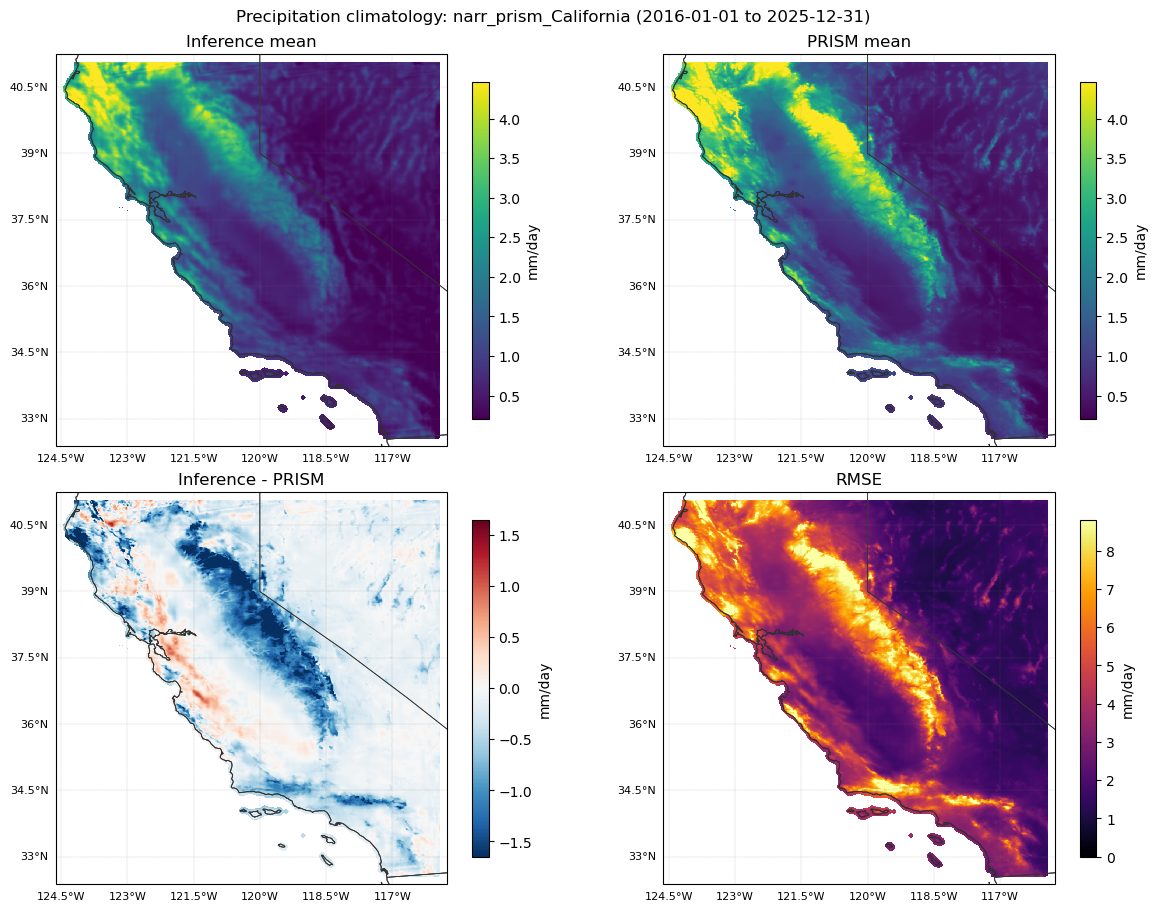

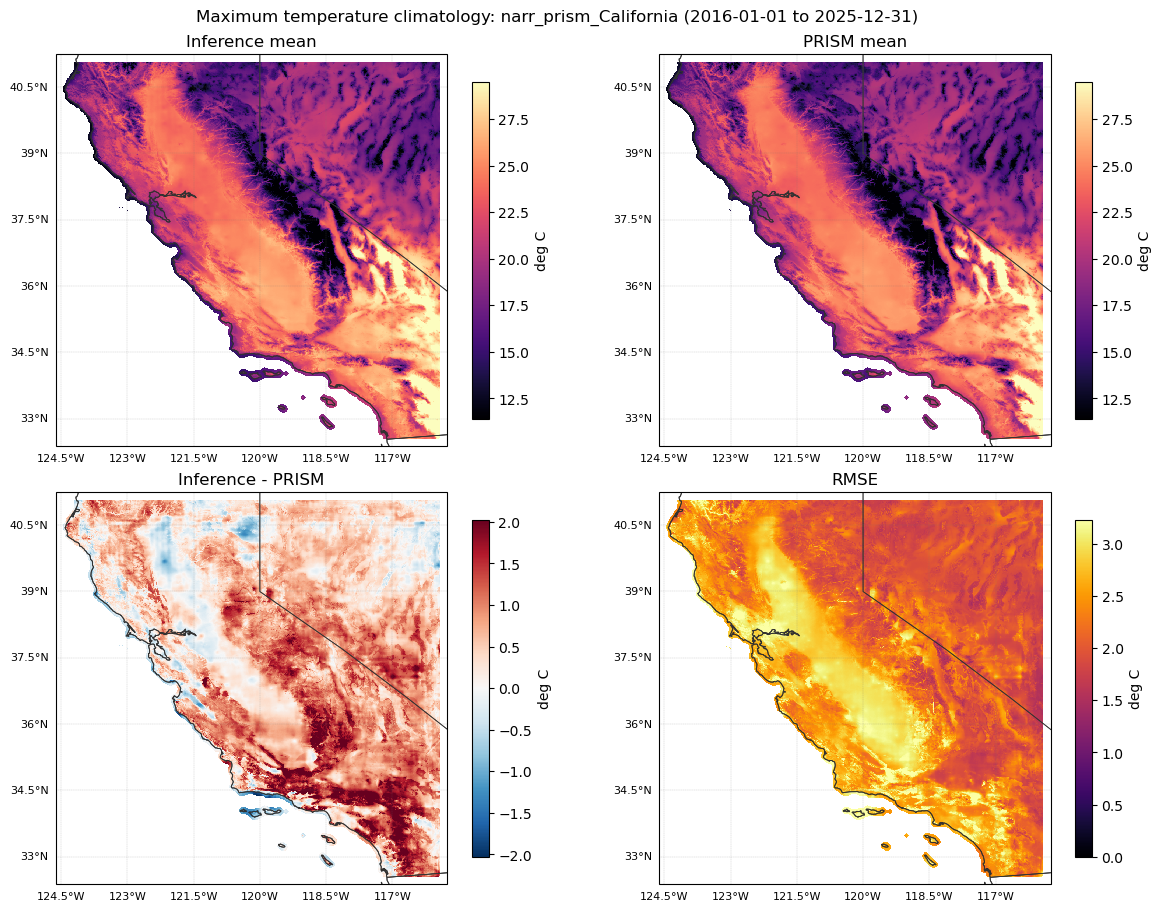

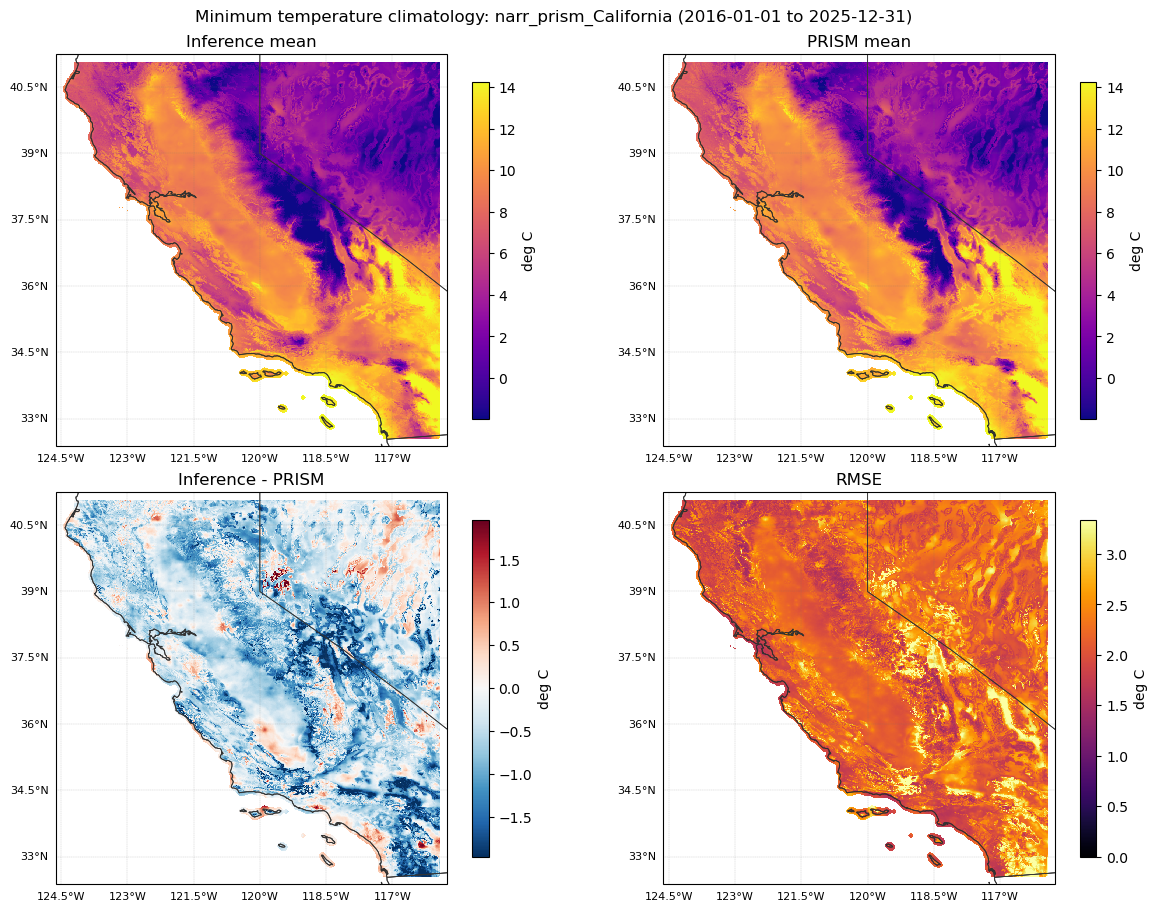

In [7]:
def plot_climatology(var):
    inf = climo[var]["inference"]
    obs = climo[var]["prism"]
    bias = climo[var]["bias"]
    rmse = climo[var]["rmse"]

    vmin, vmax = field_limits(inf, obs)
    bmin, bmax = symmetric_limits(bias)
    rmax = float(np.nanquantile(rmse.values, 0.98))
    if not np.isfinite(rmax) or rmax == 0:
        rmax = 1.0

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True, subplot_kw=map_subplot_kw())
    panels = [
        (axes[0, 0], inf, "Inference mean", VAR_CMAPS.get(var, "viridis"), vmin, vmax),
        (axes[0, 1], obs, "PRISM mean", VAR_CMAPS.get(var, "viridis"), vmin, vmax),
        (axes[1, 0], bias, "Inference - PRISM", "RdBu_r", bmin, bmax),
        (axes[1, 1], rmse, "RMSE", "inferno", 0.0, rmax),
    ]
    for ax, da, title, cmap, lo, hi in panels:
        im = da.plot(ax=ax, x="lon", y="lat", cmap=cmap, vmin=lo, vmax=hi, add_colorbar=False, **map_plot_kwargs())
        add_map_background(ax, da)
        ax.set_title(title)
        cbar = fig.colorbar(im, ax=ax, shrink=0.86)
        cbar.set_label(VAR_UNITS.get(var, ""))

    start = common_dates.min().strftime("%Y-%m-%d")
    end = common_dates.max().strftime("%Y-%m-%d")
    fig.suptitle(f"{VAR_LABELS.get(var, var)} climatology: {case_name} ({start} to {end})")
    out = OUTPUT_DIR / f"{case_name}_{var}_climatology_comparison.png"
    fig.savefig(out, dpi=160)
    print(out)
    return fig


for var in target_variables:
    plot_climatology(var)
plt.show()

## Summary Metrics

In [8]:
rows = []
for var in target_variables:
    rows.append({
        "variable": var,
        "mean_inference": float(climo[var]["inference"].mean(skipna=True)),
        "mean_prism": float(climo[var]["prism"].mean(skipna=True)),
        "mean_bias": float(climo[var]["bias"].mean(skipna=True)),
        "spatial_mean_rmse": float(climo[var]["rmse"].mean(skipna=True)),
        "valid_grid_cells": int((climo[var]["count"] > 0).sum()),
    })

metrics = pd.DataFrame(rows)
metrics_path = OUTPUT_DIR / f"{case_name}_climatology_metrics.csv"
metrics.to_csv(metrics_path, index=False)
print(metrics_path)
metrics

/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/narr_prism_California_climatology_metrics.csv


,variable,mean_inference,mean_prism,mean_bias,spatial_mean_rmse,valid_grid_cells
0,ppt,1.086763,1.379408,-0.292645,3.362612,714742
1,tmax,21.140944,20.506580,0.634364,2.322303,714742
2,tmin,6.348609,6.852247,-0.503639,2.240355,714742


## GIF Animations

Each GIF frame shows inference, PRISM, and their difference for a single day. Keep this period short for responsive rendering.

In [9]:
def load_animation_frames(var, dates):
    frames = []
    for i, date in enumerate(dates, start=1):
        print(f"{var}: frame {i}/{len(dates)} {date.date()}")
        inf_ds = open_inference_day(date)
        try:
            inf = inf_ds[var].isel(time=0).astype("float32")
            obs = open_prism_day(var, date, target_lat=inf_ds.lat, target_lon=inf_ds.lon)
            inf = inf.where(np.isfinite(obs))
            frames.append((date, inf, obs, inf - obs))
        finally:
            inf_ds.close()
    return frames


def make_comparison_gif(var, dates):
    frames = load_animation_frames(var, dates)
    if not frames:
        print(f"No frames for {var}")
        return None

    vmin, vmax = field_limits(*[item for _, inf, obs, _ in frames for item in (inf, obs)])
    diffs = [diff for _, _, _, diff in frames]
    dmin, dmax = symmetric_limits(xr.concat(diffs, dim="frame"))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), constrained_layout=True, subplot_kw=map_subplot_kw())
    titles = ["Inference", "PRISM", "Inference - PRISM"]
    cmaps = [VAR_CMAPS.get(var, "viridis"), VAR_CMAPS.get(var, "viridis"), "RdBu_r"]
    limits = [(vmin, vmax), (vmin, vmax), (dmin, dmax)]

    images = []
    first_date, first_inf, first_obs, first_diff = frames[0]
    for ax, da, title, cmap, (lo, hi) in zip(axes, [first_inf, first_obs, first_diff], titles, cmaps, limits):
        im = da.plot(ax=ax, x="lon", y="lat", cmap=cmap, vmin=lo, vmax=hi, add_colorbar=False, **map_plot_kwargs())
        add_map_background(ax, da)
        ax.set_title(title)
        cbar = fig.colorbar(im, ax=ax, shrink=0.82)
        cbar.set_label(VAR_UNITS.get(var, ""))
        images.append(im)

    suptitle = fig.suptitle("")

    def update(frame_idx):
        date, inf, obs, diff = frames[frame_idx]
        for im, da in zip(images, [inf, obs, diff]):
            im.set_array(np.asarray(da.values).ravel())
        suptitle.set_text(f"{VAR_LABELS.get(var, var)} daily comparison: {date.strftime('%Y-%m-%d')}")
        return images + [suptitle]

    anim = FuncAnimation(fig, update, frames=len(frames), interval=1000 / GIF_FPS, blit=False)
    out = OUTPUT_DIR / f"{case_name}_{var}_{dates.min().strftime('%Y%m%d')}_{dates.max().strftime('%Y%m%d')}.gif"
    anim.save(out, writer=PillowWriter(fps=GIF_FPS))
    plt.close(fig)
    print(out)
    return out


if MAKE_GIFS:
    gif_dates = existing_common_dates(GIF_START, GIF_END)
    if len(gif_dates) == 0:
        raise FileNotFoundError(f"No common inference/PRISM dates found for GIF period {GIF_START} to {GIF_END}")
    print(f"GIF dates: {len(gif_dates)} ({gif_dates.min().date()} to {gif_dates.max().date()})")
    gif_paths = [make_comparison_gif(var, gif_dates) for var in target_variables]
else:
    gif_paths = []

gif_paths

GIF dates: 31 (2025-07-01 to 2025-07-31)
ppt: frame 1/31 2025-07-01
ppt: frame 2/31 2025-07-02
ppt: frame 3/31 2025-07-03
ppt: frame 4/31 2025-07-04
ppt: frame 5/31 2025-07-05
ppt: frame 6/31 2025-07-06
ppt: frame 7/31 2025-07-07
ppt: frame 8/31 2025-07-08
ppt: frame 9/31 2025-07-09
ppt: frame 10/31 2025-07-10
ppt: frame 11/31 2025-07-11
ppt: frame 12/31 2025-07-12
ppt: frame 13/31 2025-07-13
ppt: frame 14/31 2025-07-14
ppt: frame 15/31 2025-07-15
ppt: frame 16/31 2025-07-16
ppt: frame 17/31 2025-07-17
ppt: frame 18/31 2025-07-18
ppt: frame 19/31 2025-07-19
ppt: frame 20/31 2025-07-20
ppt: frame 21/31 2025-07-21
ppt: frame 22/31 2025-07-22
ppt: frame 23/31 2025-07-23
ppt: frame 24/31 2025-07-24
ppt: frame 25/31 2025-07-25
ppt: frame 26/31 2025-07-26
ppt: frame 27/31 2025-07-27
ppt: frame 28/31 2025-07-28
ppt: frame 29/31 2025-07-29
ppt: frame 30/31 2025-07-30
ppt: frame 31/31 2025-07-31
/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/narr_prism_California_ppt_2025070

[PosixPath('/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/narr_prism_California_ppt_20250701_20250731.gif'),
 PosixPath('/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/narr_prism_California_tmax_20250701_20250731.gif'),
 PosixPath('/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/narr_prism_California_tmin_20250701_20250731.gif')]